In [1]:
%%capture
# Only need to run the first time.
!pip install -U git+https://github.com/Deep-Learning-Profiling-Tools/triton-viz
!pip install jaxtyping

In [2]:
import torch
import triton
from torch import Tensor
import triton.language as tl
import jaxtyping
from jaxtyping import Float32, Int32
import triton_viz
import inspect

In [3]:
# @title Setup

def triton_viz_launch():
    # helper utility to launch triton-viz in Colab
    # if you're running locally, you can replace "triton_viz_launch" with "triton_viz.launch(share=False)"

    import time
    triton_viz.launch(share=True)
    try:
        while True:
            time.sleep(100)
    except KeyboardInterrupt:
        pass

def test(puzzle, puzzle_spec, nelem={}, B={"B0": 32}, viz=True):
    B = dict(B)
    if "N1" in nelem and "B1" not in B:
        B["B1"] = 32
    if "N2" in nelem and "B2" not in B:
        B["B2"] = 32

    triton_viz.clear()
    torch.manual_seed(0)
    signature = inspect.signature(puzzle_spec)
    args = {}
    for n, p in signature.parameters.items():
        print(p)
        args[n + "_ptr"] = ([d.size for d in p.annotation.dims], p)
    args["z_ptr"] = ([d.size for d in signature.return_annotation.dims], None)

    tt_args = []
    for k, (v, t) in args.items():
        tt_args.append(torch.rand(*v) - 0.5)
        if t is not None and t.annotation.dtypes[0] == "int32":
            tt_args[-1] = torch.randint(-100000, 100000, v)
    grid = lambda meta: (triton.cdiv(nelem["N0"], meta["B0"]),
                         triton.cdiv(nelem.get("N1", 1), meta.get("B1", 1)),
                         triton.cdiv(nelem.get("N2", 1), meta.get("B2", 1)))

    #for k, v in args.items():
    #    print(k, v)
    triton_viz.trace("tracer")(puzzle)[grid](*tt_args, **B, **nelem)
    z = tt_args[-1]
    tt_args = tt_args[:-1]
    z_ = puzzle_spec(*tt_args)
    match = torch.allclose(z, z_, rtol=1e-3, atol=1e-3)
    print("Results match:",  match)
    failures = None
    if viz:
        failures = triton_viz_launch()
    if not match or failures:
        if failures:
            print("Invalid Access:", failures)
        print("Yours:", z)
        print("Spec:", z_)
        print(torch.isclose(z, z_))
        return
    # PUPPIES!
    from IPython.display import HTML
    import random
    print("Correct!")
    pups = [
    "2m78jPG",
    "pn1e9TO",
    "MQCIwzT",
    "udLK6FS",
    "ZNem5o3",
    "DS2IZ6K",
    "aydRUz8",
    "MVUdQYK",
    "kLvno0p",
    "wScLiVz",
    "Z0TII8i",
    "F1SChho",
    "9hRi2jN",
    "lvzRF3W",
    "fqHxOGI",
    "1xeUYme",
    "6tVqKyM",
    "CCxZ6Wr",
    "lMW0OPQ",
    "wHVpHVG",
    "Wj2PGRl",
    "HlaTE8H",
    "k5jALH0",
    "3V37Hqr",
    "Eq2uMTA",
    "Vy9JShx",
    "g9I2ZmK",
    "Nu4RH7f",
    "sWp0Dqd",
    "bRKfspn",
    "qawCMl5",
    "2F6j2B4",
    "fiJxCVA",
    "pCAIlxD",
    "zJx2skh",
    "2Gdl1u7",
    "aJJAY4c",
    "ros6RLC",
    "DKLBJh7",
    "eyxH0Wc",
    "rJEkEw4"]
    return HTML("""
    <video alt="test" controls autoplay=1>
        <source src="https://openpuppies.com/mp4/%s.mp4"  type="video/mp4">
    </video>
    """%(random.sample(pups, 1)[0]))

## Puzzle 9: Simple FlashAttention

A scalar version of FlashAttention.

Uses zero programs. Block size `B0` represents `k` of length `N0`.
Block size `B0` represents `q` of length `N0`. Block size `B0` represents `v` of length `N0`.
Sequence length is `T`. Process it `B1 < T` elements at a time.  

$$z_{i} = \sum_{j} \text{softmax}(q_1 k_1, \ldots, q_T k_T)_j v_{j} \text{ for } i = 1\ldots N_0$$

This can be done in 1 loop using a similar trick from the last puzzle.

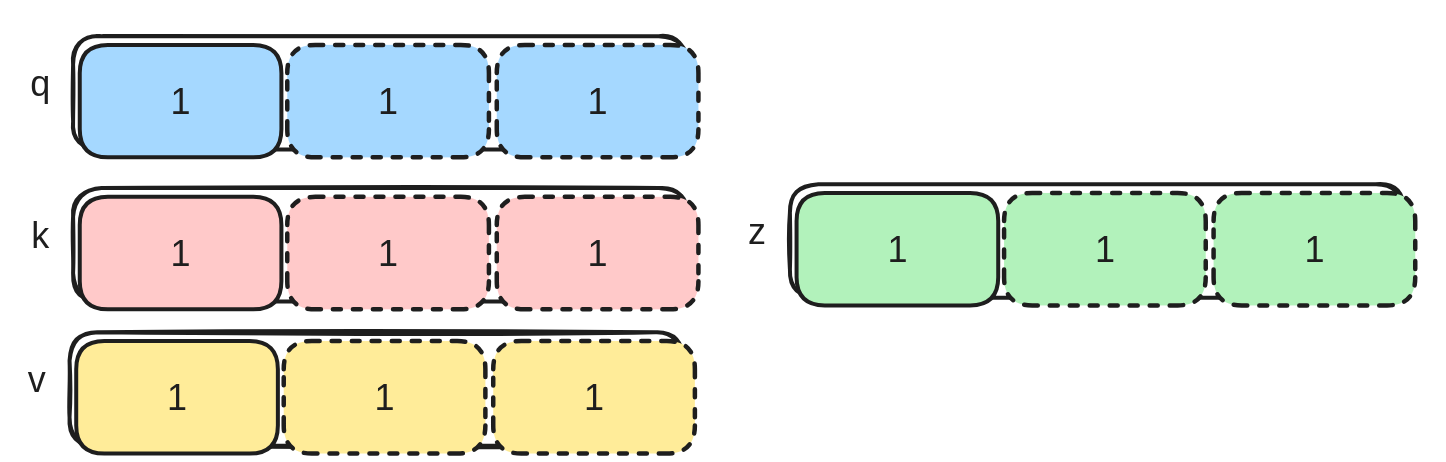

In [11]:
def flashatt_spec(
    q: Float32[Tensor, "200"],
    k: Float32[Tensor, "200"],
    v: Float32[Tensor, "200"]) -> Float32[Tensor, "200"]:
    x = q[:, None] * k[None, :]
    x_max = x.max(1, keepdim=True)[0]
    x = x - x_max
    x_exp = x.exp()
    soft =  x_exp  / x_exp.sum(1, keepdim=True)
    return (v[None, :] * soft).sum(1)


@triton.jit
def flashatt_kernel(q_ptr, k_ptr, v_ptr, z_ptr, N0, T, B0: tl.constexpr):
  """
  q chunk (B0, 1) kt (1, b1), v (b1, 1), non causal
  expected out (b0, 1)
  requirement (my intepretation): load kv in b1 chunks
  launch (tl.cdiv(N0/B0)) grid for each q chunk

  flow:
  load b0 size q chunk
  initialize max, l, accumulator

  load kv in chunks,
  for each step
  load k
  find S = QKt
  update max & rescale l and accum

  load v
  find output
  accumulate

  normalize with l once done
  """
  B1: tl.constexpr = 32
  LOG2_E: tl.constexpr = 1.4426950408889634

  chunk = tl.program_id(0)

  rows = chunk * B0 + tl.arange(0, B0)[:, None]

  q_mask = rows < N0
  q_idx = q_ptr + rows

  #intialize m, l, accum
  m = tl.full((B0, 1), float("-inf"), dtype=tl.float32) #float32 for precision
  l = tl.zeros((B0, 1), dtype=tl.float32)
  accum = tl.zeros((B0, 1), dtype=tl.float32)

  #load our q ptr
  q = tl.load(q_idx, mask=q_mask, other=0.0)
  q = q * LOG2_E #exp2 trick for fast exponentiation

  steps = tl.cdiv(T, B1)
  col_range = tl.arange(0, B1)
  for i in tl.range(0, steps, num_stages=2):
    #load k first, hold off v to avoid unneccessary register pressure
    cols = i * B1 + col_range[None, :]
    mask = cols < T

    #load
    kT_idx = k_ptr + cols
    kT = tl.load(kT_idx, mask=mask, other=0.0)

    #get S
    s = q * kT
    s = tl.where(mask, s, float("-inf")) #mask out of bounds areas

    m_new = tl.maximum(m, tl.max(s, axis=-1, keep_dims=True)) #prevent B0, B0 broadcasting as max drops the reduced column
    correction = tl.exp2((m - m_new))
    m = m_new

    #update l
    s -= m
    P = tl.exp2(s)
    l = l * correction + tl.sum(P, axis=-1, keep_dims=True)

    #load v
    v_rows = i * B1 + col_range[:, None]
    v = tl.load(v_ptr + v_rows, mask=v_rows < T, other=0.0)

    #get output
    O = tl.dot(P, v)
    accum = accum * correction + O


  #normalize O and store
  accum /= l

  O_idx = z_ptr + rows
  tl.store(O_idx, accum, mask=q_mask)

  return

test(flashatt_kernel, flashatt_spec, B={"B0": 64},
     nelem={"N0": 200, "T": 200})

q: jaxtyping.Float32[Tensor, '200']
k: jaxtyping.Float32[Tensor, '200']
v: jaxtyping.Float32[Tensor, '200']
Results match: True
 * Updating cloudflared for Linux x86_64...
 * Cloudflared updated successfully


INFO:werkzeug:127.0.0.1 - - [09/Oct/2026 05:29:45] "GET / HTTP/1.1" 200 -


Cloudflare tunnel URL: https://pot-himself-days-weights.trycloudflare.com
 * Serving Flask app 'tilelens.visualizer.interface'
 * Debug mode: off


Address already in use
Port 8000 is in use by another program. Either identify and stop that program, or start the server with a different port.


Correct!


## Puzzle 10: Two Dimensional Convolution

A batched 2D convolution.

Uses one program id axis. Block size `B0` represent the batches to process out of `N0`.
Image `x` is size is `H` by `W` with only 1 channel, and kernel `k` is size `KH` by `KW`.

$$z_{i, j, k} = \sum_{oj, ok} k_{oj,ok} \times x_{i,j + oj, k + ok} \text{ for } i = 1\ldots N_0$$



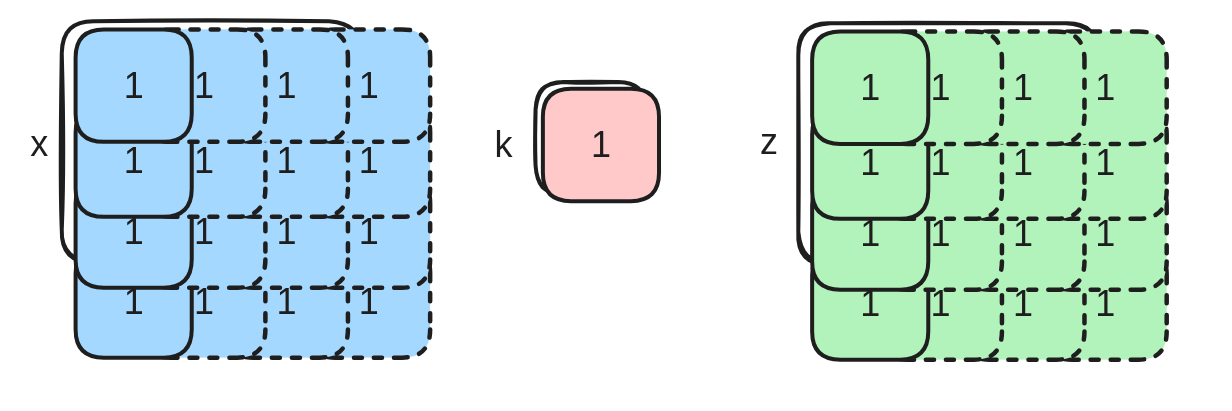

In [10]:
def conv2d_spec(x: Float32[Tensor, "4 8 8"], k: Float32[Tensor, "4 4"]) -> Float32[Tensor, "4 8 8"]:
    z = torch.zeros(4, 8, 8)
    x = torch.nn.functional.pad(x, (0, 4, 0, 4, 0, 0), value=0.0)
    print(x.shape, k.shape)
    for i in range(8):
        for j in range(8):
            z[:, i, j] = (k[None, :, :] * x[:, i: i+4, j: j + 4]).sum(1).sum(1)
    return z


@triton.jit
def conv2d_kernel(x_ptr, k_ptr, z_ptr, N0, H, W, KH: tl.constexpr, KW: tl.constexpr, B0: tl.constexpr):
  """
  parallelize processing across batches
  each batch, load the kernel, iterate over the image, and return the output
  input is (B0, H, W)
  output (B0, H, W)
  """
  pid_0 = tl.program_id(0)
  k_ptr = k_ptr + tl.arange(0, KH)[:, None] * KW + tl.arange(0, KW)[None, :]

  row_range = tl.arange(0, KH)[:, None]
  col_range = tl.arange(0, KW)[None, :]
  batch_range = tl.arange(0, B0)

  batches = batch_range + pid_0 * B0
  batch_mask = batches[:, None, None] < N0

  kernel = tl.load(k_ptr)[None, :, :]

  for row in tl.static_range(0, H):
    rows = row + row_range
    row_mask = rows < H

    for col in tl.range(0, W, num_stages=3):
      #load the image patch with zero padding
      cols = col + col_range
      col_mask = cols < W

      mask = batch_mask & (row_mask & col_mask)
      patch_idx = (
          x_ptr +
          batches[:, None, None] * W * H+
          rows * W +
          cols
      )

      patch = tl.load(patch_idx, mask=mask, other=0.0)

      #perform convolution and store
      conv = tl.sum(tl.sum(patch * kernel, axis=-1), axis=-1) #(B0, KH, KW) -> (B0, )
      out_ptr = (
          z_ptr +
          batches * W * H +
          row * W +
          col
      )

      tl.store(out_ptr, conv, mask=batches < N0)

  return

test(conv2d_kernel, conv2d_spec, B={"B0": 1}, nelem={"N0": 4, "H": 8, "W": 8, "KH": 4, "KW": 4})

x: jaxtyping.Float32[Tensor, '4 8 8']
k: jaxtyping.Float32[Tensor, '4 4']
torch.Size([4, 12, 12]) torch.Size([4, 4])
Results match: True
 * Updating cloudflared for Linux x86_64...
 * Cloudflared updated successfully


INFO:werkzeug:127.0.0.1 - - [09/Oct/2026 05:29:37] "GET / HTTP/1.1" 200 -


Cloudflare tunnel URL: https://discuss-chargers-approval-restored.trycloudflare.com
 * Serving Flask app 'tilelens.visualizer.interface'
 * Debug mode: off


Address already in use
Port 8000 is in use by another program. Either identify and stop that program, or start the server with a different port.


Correct!


## Puzzle 11: Matrix Multiplication

A blocked matrix multiplication.

Uses three program id axes. Block size `B2` represent the batches to process out of `N2`.
Block size `B0` represent the rows of `x` to process out of `N0`. Block size `B1` represent the cols of `y` to process out of `N1`. The middle shape is `MID`.

$$z_{i, j, k} = \sum_{l} x_{i,j, l} \times y_{i, l, k} \text{ for } i = 1\ldots N_2, j = 1\ldots N_0, k = 1\ldots N_1$$

You are allowed to use `tl.dot` which computes a smaller mat mul.

Hint: the main trick is that you can split a matmul into smaller parts.

$$z_{i, j, k} = \sum_{l=1}^{L/2} x_{i,j, l} \times y_{i, l, k} +  \sum_{l=L/2}^{L} x_{i,j, l} \times y_{i, l, k} $$


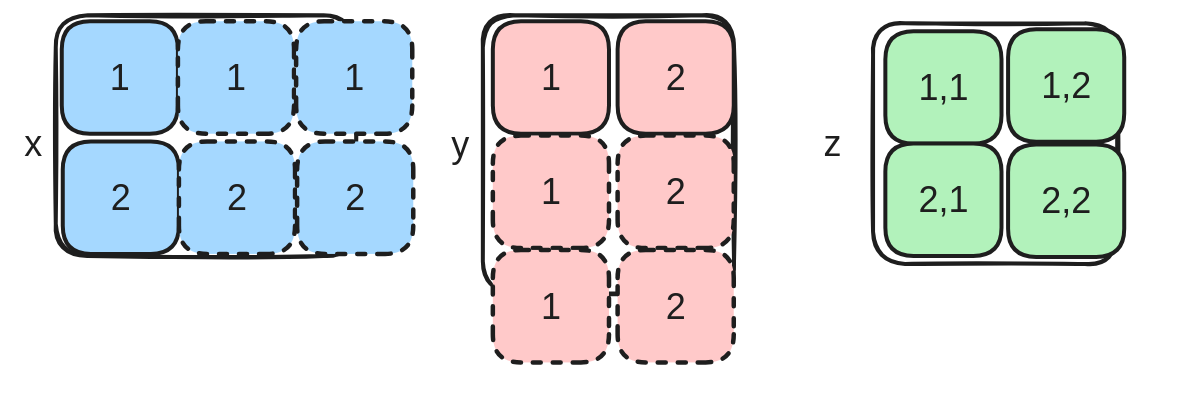

In [12]:
def dot_spec(x: Float32[Tensor, "4 32 32"], y: Float32[Tensor, "4 32 32"]) -> Float32[Tensor, "4 32 32"]:
    return x @ y

@triton.jit
def dot_kernel(x_ptr, y_ptr, z_ptr, N0, N1, N2, MID, B0: tl.constexpr, B1: tl.constexpr, B2: tl.constexpr, B_MID: tl.constexpr):
  """
  B0 -> rows of x, B1 -> cols of y, B2 -> batches
  each program launch computes (B2, B0, d) @ (B2, d, B1) -> (B2, B0, B1).
  writes to the the relevant row, columns
  we need to chunk, so we declare a (B2, B0, B1) size matrix

  """
  pid_0 = tl.program_id(0) #x parallelism
  pid_1 = tl.program_id(1) #y parallelism
  pid_2 = tl.program_id(2) #batch parallelism

  x_row_range = tl.arange(0, B0)
  y_col_range = tl.arange(0, B1)
  b_mid_range = tl.arange(0, B_MID)
  batches = tl.arange(0, B2) + pid_2 * B2

  #shift ptrs by rows
  x_ptr += pid_0 * B0 * MID
  y_ptr += pid_1 * B1

  #init accumulator
  accum = tl.zeros((B2, B0, B1), dtype=tl.float32)

  #initialize batch, row and col mask for x and y respectively
  x_rows = pid_0 * B0 + x_row_range
  x_row_mask = x_rows[:, None] < N0

  y_cols = pid_1 * B1 + y_col_range
  y_col_mask = y_cols[None, :] < N1

  batch_mask = batches[:, None, None] < N2
  #chunk our matmul, chunk col for x, chunk rows for y
  steps = tl.cdiv(MID, B_MID)
  for i in tl.range(0, steps, num_stages=3):
    #load x
    x_cols = i * B_MID + b_mid_range
    col_mask = x_cols[None, :] < MID

    x_idx = (
        x_ptr +
        batches[:, None, None] * N0 * MID +
        x_row_range[None, :, None] * MID +
        x_cols[None, None, :]
    )

    x_mask = batch_mask & (x_row_mask & col_mask)
    x = tl.load(x_idx, mask=x_mask, other=0.0)

    #load y
    y_rows = x_cols
    row_mask = y_rows[:, None] < MID

    y_idx = (
        y_ptr +
        batches[:, None, None] * N1 * MID +
        y_rows[None, :, None] * N1 +
        y_col_range[None, None, :]
    )

    y_mask = batch_mask & (y_col_mask & row_mask)
    y = tl.load(y_idx, mask=y_mask, other=0.0)

    #matmul, accum
    accum += tl.dot(x, y)

  #find idx and write back
  z_idx = (
      z_ptr +
      batches[:, None, None] * N0 * N1 +  #batch
      x_rows[None, :, None] * N1 +
      y_cols[None, None, :]
  )

  mask = batch_mask & (x_row_mask & y_col_mask)
  tl.store(z_idx, accum, mask=mask)


test(dot_kernel, dot_spec, B={"B0": 16, "B1": 16, "B2": 1, "B_MID": 16}, nelem={"N0": 32, "N1": 32, "N2": 4, "MID": 32})


x: jaxtyping.Float32[Tensor, '4 32 32']
y: jaxtyping.Float32[Tensor, '4 32 32']
Results match: True
 * Updating cloudflared for Linux x86_64...
 * Cloudflared updated successfully


INFO:werkzeug:127.0.0.1 - - [09/Oct/2026 05:29:59] "GET / HTTP/1.1" 200 -


Cloudflare tunnel URL: https://celebrate-briefly-robust-danny.trycloudflare.com
 * Serving Flask app 'tilelens.visualizer.interface'
 * Debug mode: off


Address already in use
Port 8000 is in use by another program. Either identify and stop that program, or start the server with a different port.


Correct!
